In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

%matplotlib inline

In [4]:
womens_volleyball = pd.read_csv('/content/volleyball_ncaa_div1_2022_23.csv')
womens_volleyball.head()

,Team,Conference,region,aces_per_set,assists_per_set,team_attacks_per_set,blocks_per_set,digs_per_set,hitting_pctg,kills_per_set,opp_hitting_pctg,W,L,win_loss_pctg
0,Lafayette,Patriot,East,2.33,11.01,34.54,1.31,13.60,0.180,11.93,0.227,8,15,0.348
1,Delaware St.,MEAC,Southeast,2.20,11.45,29.98,2.17,12.58,0.250,12.12,0.137,24,7,0.774
2,Yale,Ivy League,East,2.15,12.60,35.39,1.82,15.29,0.242,13.90,0.155,23,3,0.885
3,Coppin St.,MEAC,Southeast,2.15,10.56,32.52,1.81,14.22,0.194,11.54,0.170,23,11,0.676
4,Saint Louis,Atlantic 10,East,2.03,11.61,34.10,1.83,14.27,0.201,12.40,0.188,18,13,0.581


## Data Assessment

##What is the structure or shape of the data?

In [5]:
print(f"The `womens_volleyball` DataFrame has {womens_volleyball.shape[0]} rows and {womens_volleyball.shape[1]} columns.")

The `womens_volleyball` DataFrame has 334 rows and 14 columns.


## What is the granularity of the data?


**Answer: Each row represents an NCAA Division I women’s volleyball team’s statistics for the 2022–2023 season. The columns include performance metrics (such as aces, assists, kills, and hitting percentage) along with team information like name, conference, and region.**

## What is the scope and completeness of the data?


In [6]:
print("Missing values in each column:")
print(womens_volleyball.isnull().sum())

Missing values in each column:
Team                    0
Conference              1
region                  0
aces_per_set            0
assists_per_set         0
team_attacks_per_set    0
blocks_per_set          0
digs_per_set            0
hitting_pctg            2
kills_per_set           0
opp_hitting_pctg        0
W                       0
L                       0
win_loss_pctg           0
dtype: int64


**The womens_volleyball dataset contains statistics for NCAA Division I women’s volleyball teams from the 2022–2023 season, where each row represents a team and the columns include performance metrics such as aces, assists, kills, hitting percentage, blocks, and win/loss records. The dataset is mostly complete, with only 1 missing value in Conference and 2 missing values in hitting_pctg, making it generally reliable for analyzing team performance.**

## What is the temporality of the data, or how does the data relate to time?

**Answer: The womens_volleyball dataset covers the 2022–2023 season, as indicated by the dataset.**

##What is the faithfulness of the data, or how well does the data capture reality?

**The womens_volleyball dataset is likely highly faithful because it comes from an official NCAA Division I source and includes standard volleyball statistics that are usually recorded consistently. Although small errors may occur due to recording differences or human error, the dataset is generally reliable and accurately represents the 2022–2023 season.**

# Cleaning your data

**Identify and count missing values within dataframe.**

In [7]:
print(womens_volleyball.isnull().sum())

Team                    0
Conference              1
region                  0
aces_per_set            0
assists_per_set         0
team_attacks_per_set    0
blocks_per_set          0
digs_per_set            0
hitting_pctg            2
kills_per_set           0
opp_hitting_pctg        0
W                       0
L                       0
win_loss_pctg           0
dtype: int64


**Missing values in the "conference" column within dataframe.**

In [8]:
womens_volleyball['Conference'].fillna('Unknown', inplace=True)
print("Missing values after handling 'Conference':")
print(womens_volleyball.isnull().sum())

Missing values after handling 'Conference':
Team                    0
Conference              0
region                  0
aces_per_set            0
assists_per_set         0
team_attacks_per_set    0
blocks_per_set          0
digs_per_set            0
hitting_pctg            2
kills_per_set           0
opp_hitting_pctg        0
W                       0
L                       0
win_loss_pctg           0
dtype: int64


/tmp/ipykernel_140/348809840.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  womens_volleyball['Conference'].fillna('Unknown', inplace=True)


**Missing values in the "hitting_pctg" column within dataframe.**

In [9]:
mean_hitting_pctg = womens_volleyball['hitting_pctg'].mean()
womens_volleyball['hitting_pctg'].fillna(mean_hitting_pctg, inplace=True)
print("Missing values after handling 'hitting_pctg':")
print(womens_volleyball.isnull().sum())

Missing values after handling 'hitting_pctg':
Team                    0
Conference              0
region                  0
aces_per_set            0
assists_per_set         0
team_attacks_per_set    0
blocks_per_set          0
digs_per_set            0
hitting_pctg            0
kills_per_set           0
opp_hitting_pctg        0
W                       0
L                       0
win_loss_pctg           0
dtype: int64


/tmp/ipykernel_140/854095104.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  womens_volleyball['hitting_pctg'].fillna(mean_hitting_pctg, inplace=True)


**Confirm cleaning data successful.**

In [10]:
print("Missing values after cleaning:")
print(womens_volleyball.isnull().sum())

Missing values after cleaning:
Team                    0
Conference              0
region                  0
aces_per_set            0
assists_per_set         0
team_attacks_per_set    0
blocks_per_set          0
digs_per_set            0
hitting_pctg            0
kills_per_set           0
opp_hitting_pctg        0
W                       0
L                       0
win_loss_pctg           0
dtype: int64


**Assessment of data.**

In [11]:
print("Descriptive statistics for numerical columns:")
print(womens_volleyball.describe())

Descriptive statistics for numerical columns:
       aces_per_set  assists_per_set  team_attacks_per_set  blocks_per_set  \
count    334.000000       334.000000            334.000000      334.000000   
mean       1.465359        11.431617             34.457066        2.057365   
std        0.233186         1.196959              1.940032        0.381777   
min        0.900000         4.440000             24.250000        0.600000   
25%        1.310000        10.872500             33.352500        1.810000   
50%        1.455000        11.540000             34.470000        2.070000   
75%        1.610000        12.137500             35.885000        2.300000   
max        2.330000        13.800000             39.780000        3.330000   

       digs_per_set  hitting_pctg  kills_per_set  opp_hitting_pctg  \
count    334.000000    334.000000     334.000000        334.000000   
mean      14.352096      0.207864      12.365329          0.207596   
std        1.465299      0.040370       1

**Display data type of each column within dataframe.**

In [12]:
print("Data types of all columns:")
print(womens_volleyball.dtypes)

Data types of all columns:
Team                     object
Conference               object
region                   object
aces_per_set            float64
assists_per_set         float64
team_attacks_per_set    float64
blocks_per_set          float64
digs_per_set            float64
hitting_pctg            float64
kills_per_set           float64
opp_hitting_pctg        float64
W                         int64
L                         int64
win_loss_pctg           float64
dtype: object


## Describe what steps (if any) you took to clean your data on your webpage.  In particular, even if you did not need to clean your data, you must still state this on your webpage for full credit.

**The dataset was first checked for missing values. It was found that the Conference column had 1 missing value and the hitting_pctg column had 2 missing values. The missing value in the Conference column was replaced with "Unknown" since it is a categorical variable. The missing values in hitting_pctg were replaced with the mean of the column because it is a numerical variable. These steps ensured the dataset was complete before performing the analysis.**

## Single variable distribution plots

**Plot win/loss percentage.**

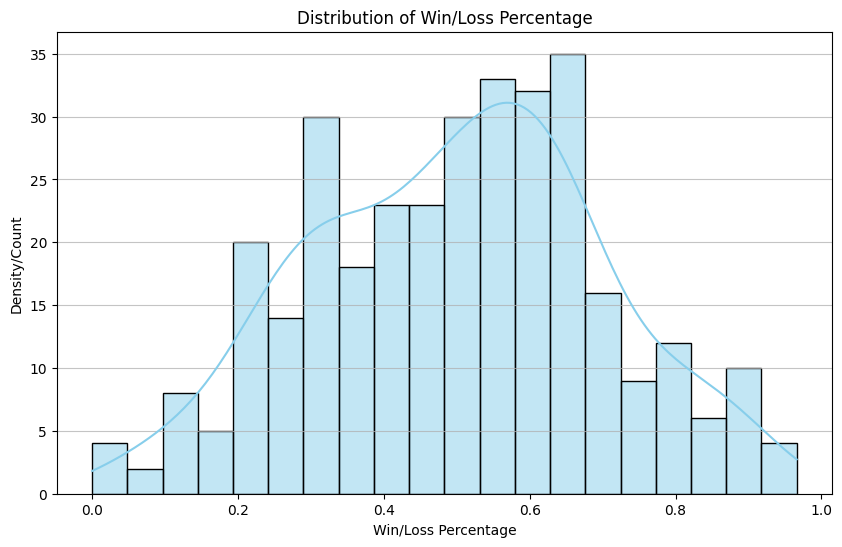

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(womens_volleyball['win_loss_pctg'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Win/Loss Percentage')
plt.xlabel('Win/Loss Percentage')
plt.ylabel('Density/Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Describe Win/Loss Percentage Plot




**Answer: The histogram and KDE plot of win_loss_pctg show a fairly symmetrical distribution with a slight left skew. Most teams have win/loss percentages around 0.50, meaning many teams have balanced records. The values range from about 0.00 to 0.97, showing a wide spread in team performance, with a few teams having very high or very low records.**

**Plot kills per set.**

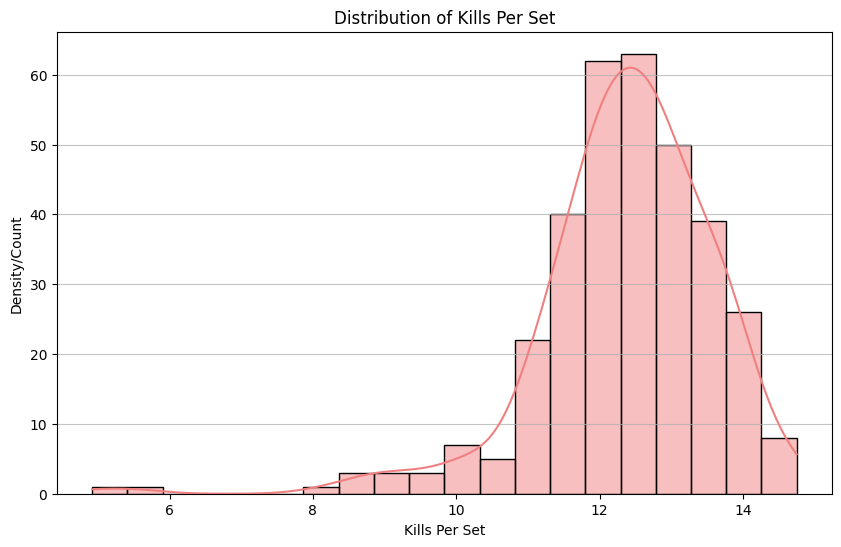

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(womens_volleyball['kills_per_set'], kde=True, bins=20, color='lightcoral')
plt.title('Distribution of Kills Per Set')
plt.xlabel('Kills Per Set')
plt.ylabel('Density/Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Describe Kills Per Set Plot




**Answer: The histogram and KDE plot for kills_per_set show a roughly symmetrical distribution. Most teams average around 12–13 kills per set, with values ranging from about 5 to 15, indicating moderate variation in team performance. There are no major outliers, though a few teams have slightly higher or lower values.**

**Plot Blocks per set.**

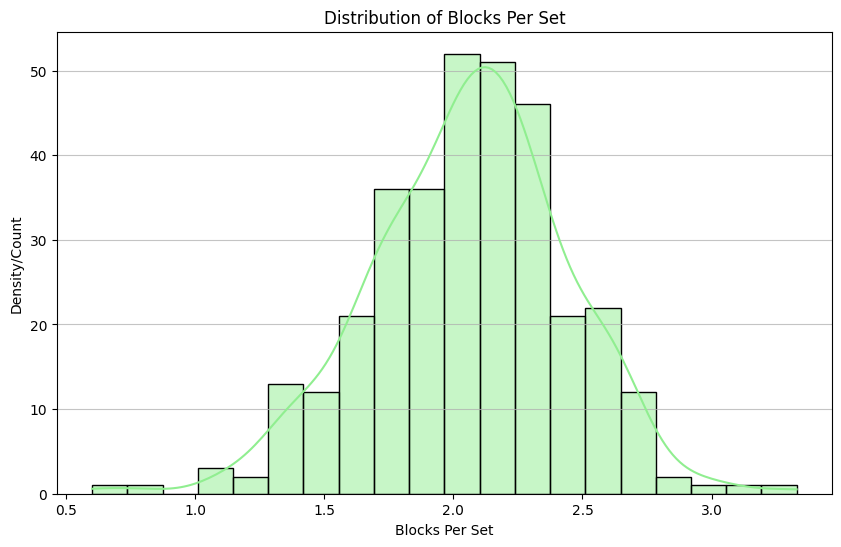

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(womens_volleyball['blocks_per_set'], kde=True, bins=20, color='lightgreen')
plt.title('Distribution of Blocks Per Set')
plt.xlabel('Blocks Per Set')
plt.ylabel('Density/Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Describe Blocks Per Set Plot



**Answer: The histogram and KDE plot for blocks_per_set show a roughly symmetrical distribution, with most teams averaging around 2.0 blocks per set. The values range from about 0.6 to 3.3, indicating moderate variation in blocking performance. There are no major outliers, though a few teams have slightly higher or lower values.**

**Plot conference distribution.**

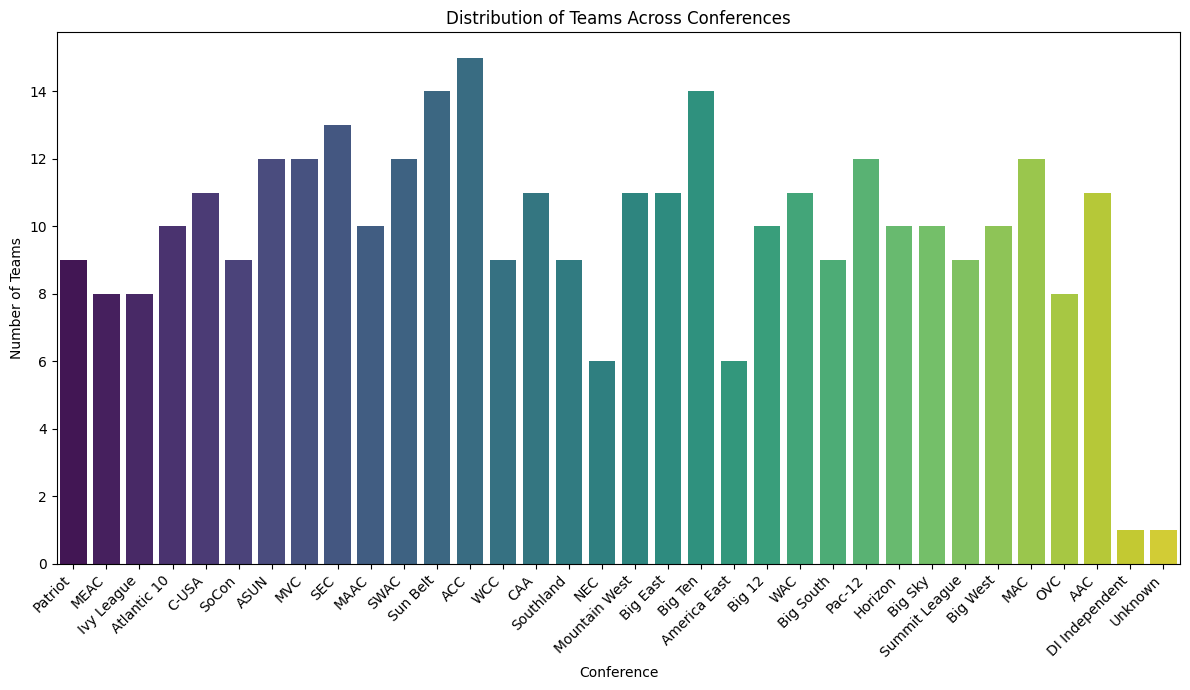

In [16]:
plt.figure(figsize=(12, 7))
sns.countplot(data=womens_volleyball, x='Conference', hue='Conference', palette='viridis', legend=False)
plt.title('Distribution of Teams Across Conferences')
plt.xlabel('Conference')
plt.ylabel('Number of Teams')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Describe Conference Distribution Plot



**Answer: The bar chart shows that the number of teams varies across conferences. Some conferences, such as the Ohio Valley, Missouri Valley, Big Ten, and Atlantic 10, have more teams, while others have fewer. The “Unknown” category represents a small number of teams with missing conference information.**

## Multiple variable plots

**Plot kills per set and win/loss percentage.**

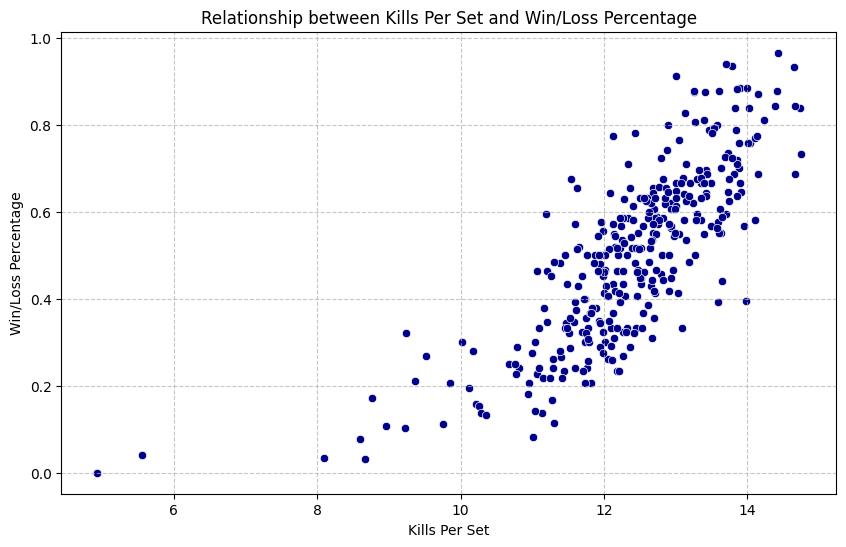

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=womens_volleyball, x='kills_per_set', y='win_loss_pctg', color='darkblue')
plt.title('Relationship between Kills Per Set and Win/Loss Percentage')
plt.xlabel('Kills Per Set')
plt.ylabel('Win/Loss Percentage')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Describe Kills Per Set vs. Win/Loss Percentage Plot




**Answer: The scatter plot shows a positive relationship between kills_per_set and win_loss_pctg. Teams with more kills per set generally have higher win percentages. The points follow a loose upward trend, suggesting offensive performance plays an important role in team success.**

**Plot hitting percentage and win/loss percentage.**

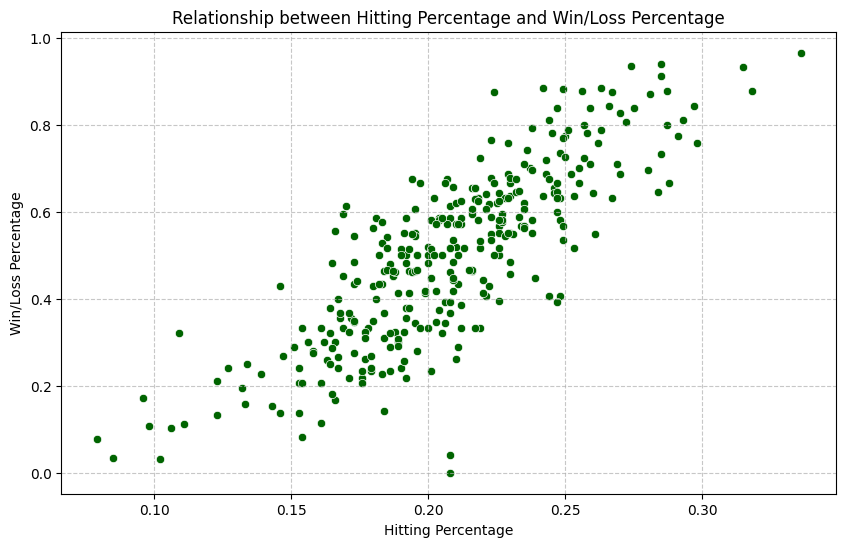

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=womens_volleyball, x='hitting_pctg', y='win_loss_pctg', color='darkgreen')
plt.title('Relationship between Hitting Percentage and Win/Loss Percentage')
plt.xlabel('Hitting Percentage')
plt.ylabel('Win/Loss Percentage')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Describe Hitting Percentage vs. Win/Loss Percentage Plot


**Answer: The scatter plot shows a strong positive relationship between hitting_pctg and win_loss_pctg. Teams with higher hitting percentages generally have higher win percentages. The upward trend suggests that hitting efficiency is an important factor in team success.**